CAR PRICE PREDICTION - MODEL TRAINING
 الهدف: تدريب نماذج تعلم الآلة للتنبؤ بسعر السيارة المستعملة
 البيانات: cleaned_data.csv (نتيجة مرحلة EDA)
 المخرجات: model.pkl, encoders.pkl, features.pkl, metrics_report.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# إعدادات الرسومات
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*70)
print("🚗 CAR PRICE PREDICTION - MODEL TRAINING PIPELINE")
print("="*70)

🚗 CAR PRICE PREDICTION - MODEL TRAINING PIPELINE


In [5]:
# ============================================================
# 1. LOAD AND VALIDATE DATA
# ============================================================
print("\n📂 1. LOADING DATA")
print("-"*50)

df = pd.read_csv("model_ready_no_leakage.csv")
print(f"✅ Data shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"✅ Target range: {df['selling_price'].min():,.0f} - {df['selling_price'].max():,.0f} EGP")

# Check for data leakage columns (from EDA)
leakage_cols = ['log_price', 'price_per_km', 'engine_per_seat']
leakage_present = [col for col in leakage_cols if col in df.columns]
if leakage_present:
    print(f"⚠️ Warning: Leakage columns detected: {leakage_present}")
    print("   These will be dropped (they contain target information)")



📂 1. LOADING DATA
--------------------------------------------------
✅ Data shape: 13,871 rows × 15 columns
✅ Target range: 40,000 - 1,485,000 EGP
⚠️ Warning: Leakage columns detected: ['engine_per_seat']
   These will be dropped (they contain target information)


In [7]:
# ============================================================
# 2. FEATURE SELECTION
# ============================================================
print("\n🔧 2. FEATURE ENGINEERING & SELECTION")
print("-"*50)

# تعريف الأعمدة
numerical_features = ['vehicle_age', 'km_driven', 'engine', 'max_power', 'seats']
categorical_features = ['brand', 'fuel_type', 'transmission_type', 'seller_type']
target = 'selling_price'

# إزالة أعمدة التسريب إن وجدت
for col in leakage_present:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
        print(f"   ✅ Removed leakage column: {col}")

print(f"📊 Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"📊 Categorical features ({len(categorical_features)}): {categorical_features}")




🔧 2. FEATURE ENGINEERING & SELECTION
--------------------------------------------------
📊 Numerical features (5): ['vehicle_age', 'km_driven', 'engine', 'max_power', 'seats']
📊 Categorical features (4): ['brand', 'fuel_type', 'transmission_type', 'seller_type']


In [8]:
# ============================================================
# 3. ENCODE CATEGORICAL VARIABLES
# ============================================================
print("\n📝 3. ENCODING CATEGORICAL VARIABLES")
print("-"*50)

label_encoders = {}
encoding_mapping = {}

for col in categorical_features:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col])
    label_encoders[col] = le
    encoding_mapping[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"   ✅ {col}: {len(le.classes_)} categories")
    # Print sample mapping
    sample_items = list(encoding_mapping[col].items())[:3]
    print(f"      Sample: {sample_items}")




📝 3. ENCODING CATEGORICAL VARIABLES
--------------------------------------------------
   ✅ brand: 23 categories
      Sample: [('Audi', np.int64(0)), ('BMW', np.int64(1)), ('Datsun', np.int64(2))]
   ✅ fuel_type: 4 categories
      Sample: [('CNG', np.int64(0)), ('Diesel', np.int64(1)), ('LPG', np.int64(2))]
   ✅ transmission_type: 2 categories
      Sample: [('Automatic', np.int64(0)), ('Manual', np.int64(1))]
   ✅ seller_type: 3 categories
      Sample: [('Dealer', np.int64(0)), ('Individual', np.int64(1)), ('Trustmark Dealer', np.int64(2))]


In [9]:
# ============================================================
# 4. PREPARE FEATURE MATRIX
# ============================================================
print("\n🎯 4. PREPARING FEATURE MATRIX")
print("-"*50)

encoded_features = [f'{col}_encoded' for col in categorical_features]
all_features = numerical_features + encoded_features

X = df[all_features]
y = df[target]

print(f"✅ Feature matrix shape: {X.shape}")
print(f"✅ Features: {all_features}")

# Check for any missing values
print(f"✅ Missing values in X: {X.isnull().sum().sum()}")
print(f"✅ Missing values in y: {y.isnull().sum()}")




🎯 4. PREPARING FEATURE MATRIX
--------------------------------------------------
✅ Feature matrix shape: (13871, 9)
✅ Features: ['vehicle_age', 'km_driven', 'engine', 'max_power', 'seats', 'brand_encoded', 'fuel_type_encoded', 'transmission_type_encoded', 'seller_type_encoded']
✅ Missing values in X: 0
✅ Missing values in y: 0


In [10]:
# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================
print("\n✂️ 5. TRAIN-TEST SPLIT")
print("-"*50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"✅ Training set: {X_train.shape[0]:,} samples")
print(f"✅ Test set: {X_test.shape[0]:,} samples")
print(f"✅ Train/Test ratio: {len(X_train)/len(X):.1%} / {len(X_test)/len(X):.1%}")



✂️ 5. TRAIN-TEST SPLIT
--------------------------------------------------
✅ Training set: 11,096 samples
✅ Test set: 2,775 samples
✅ Train/Test ratio: 80.0% / 20.0%


In [11]:
# ============================================================
# 6. FEATURE SCALING (OPTIONAL - FOR LINEAR MODELS)
# ============================================================
print("\n📏 6. FEATURE SCALING")
print("-"*50)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Scaler fitted on {X_train.shape[1]} features")
print(f"✅ Training data scaled (mean=0, std=1)")

# Save scaler for later use
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved as 'scaler.pkl'")


📏 6. FEATURE SCALING
--------------------------------------------------
✅ Scaler fitted on 9 features
✅ Training data scaled (mean=0, std=1)
✅ Scaler saved as 'scaler.pkl'


In [12]:
# ============================================================
# 7. TRAIN MULTIPLE MODELS
# ============================================================
print("\n🤖 7. TRAINING MODELS")
print("="*50)

models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=0.001)
}

results = {}
best_model = None
best_score = -np.inf
best_name = None

for name, model in models.items():
    print(f"\n📈 Training {name}...")
    
    # Use scaled data for linear models, original for tree-based
    if name in ['Linear Regression', 'Ridge (L2)', 'Lasso (L1)']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape,
        'model': model
    }
    
    print(f"  ✅ MAE:  {mae:>10,.0f} EGP")
    print(f"  ✅ RMSE: {rmse:>10,.0f} EGP")
    print(f"  ✅ R²:   {r2:>10.4f}")
    print(f"  ✅ MAPE: {mape:>9.2f}%")
    
    if r2 > best_score:
        best_score = r2
        best_model = model
        best_name = name

print("\n" + "="*50)
print(f"🏆 BEST MODEL: {best_name}")
print(f"   R² Score: {best_score:.4f} ({best_score*100:.2f}% variance explained)")
print("="*50)




🤖 7. TRAINING MODELS

📈 Training Random Forest...
  ✅ MAE:      73,432 EGP
  ✅ RMSE:    101,133 EGP
  ✅ R²:       0.8708
  ✅ MAPE:     14.64%

📈 Training Gradient Boosting...
  ✅ MAE:      76,149 EGP
  ✅ RMSE:    102,082 EGP
  ✅ R²:       0.8684
  ✅ MAPE:     15.18%

📈 Training Linear Regression...
  ✅ MAE:     112,698 EGP
  ✅ RMSE:    150,523 EGP
  ✅ R²:       0.7139
  ✅ MAPE:     25.57%

📈 Training Ridge (L2)...
  ✅ MAE:     112,698 EGP
  ✅ RMSE:    150,524 EGP
  ✅ R²:       0.7139
  ✅ MAPE:     25.57%

📈 Training Lasso (L1)...
  ✅ MAE:     112,698 EGP
  ✅ RMSE:    150,523 EGP
  ✅ R²:       0.7139
  ✅ MAPE:     25.57%

🏆 BEST MODEL: Random Forest
   R² Score: 0.8708 (87.08% variance explained)


In [13]:
# ============================================================
# 8. CROSS-VALIDATION
# ============================================================
print("\n🔄 8. CROSS-VALIDATION (5-Fold)")
print("-"*50)

# Use appropriate data based on model type
if best_name in ['Linear Regression', 'Ridge (L2)', 'Lasso (L1)']:
    X_for_cv = X_train_scaled
else:
    X_for_cv = X_train

cv_scores = cross_val_score(best_model, X_for_cv, y_train, cv=5, scoring='r2')
print(f"✅ CV R² scores: {cv_scores}")
print(f"✅ Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

if cv_scores.mean() < best_score - 0.05:
    print("⚠️ Warning: Large gap between test score and CV score - possible overfitting")



🔄 8. CROSS-VALIDATION (5-Fold)
--------------------------------------------------
✅ CV R² scores: [0.86123202 0.86758893 0.85465519 0.86288657 0.85515722]
✅ Mean CV R²: 0.8603 (+/- 0.0098)


In [14]:
# ============================================================
# 9. HYPERPARAMETER TUNING (OPTIONAL - FOR BEST MODEL)
# ============================================================
print("\n🔧 9. HYPERPARAMETER TUNING")
print("-"*50)

if best_name == 'Random Forest':
    print("Performing Grid Search for Random Forest...")
    
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    
    # Use subset for faster tuning (30% of data)
    X_sample, _, y_sample, _ = train_test_split(X_train, y_train, train_size=0.3, random_state=42)
    
    grid_search = GridSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        param_grid,
        cv=3,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_sample, y_sample)
    
    print(f"✅ Best parameters: {grid_search.best_params_}")
    print(f"✅ Best CV score: {grid_search.best_score_:.4f}")
    
    # Update best model with tuned parameters
    best_model = grid_search.best_estimator_
    best_model.fit(X_train, y_train)
    
    # Re-evaluate
    y_pred_tuned = best_model.predict(X_test)
    r2_tuned = r2_score(y_test, y_pred_tuned)
    print(f"✅ Tuned model R²: {r2_tuned:.4f}")
    
    if r2_tuned > best_score:
        best_score = r2_tuned
        print("🎉 Tuned model improved!")



🔧 9. HYPERPARAMETER TUNING
--------------------------------------------------
Performing Grid Search for Random Forest...
✅ Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
✅ Best CV score: 0.8490
✅ Tuned model R²: 0.8787
🎉 Tuned model improved!



📊 10. FEATURE IMPORTANCE ANALYSIS
--------------------------------------------------

📈 Feature Importance Ranking:
                  feature  importance
                max_power    0.534376
              vehicle_age    0.298545
                   engine    0.102877
                km_driven    0.024918
            brand_encoded    0.018774
transmission_type_encoded    0.008982
        fuel_type_encoded    0.004151
                    seats    0.004121
      seller_type_encoded    0.003256


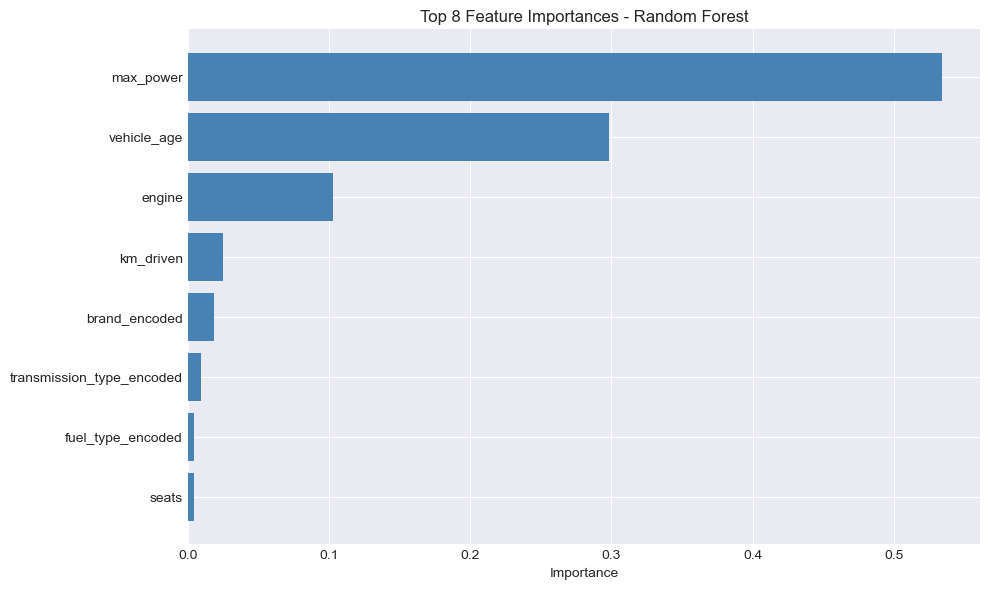

✅ Feature importance plot saved as 'feature_importance.png'


In [15]:
# ============================================================
# 10. FEATURE IMPORTANCE ANALYSIS
# ============================================================
print("\n📊 10. FEATURE IMPORTANCE ANALYSIS")
print("-"*50)

if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': all_features,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n📈 Feature Importance Ranking:")
    print(importance_df.to_string(index=False))
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'][:8], importance_df['importance'][:8], color='steelblue')
    plt.xlabel('Importance')
    plt.title('Top 8 Feature Importances - Random Forest')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Feature importance plot saved as 'feature_importance.png'")
    
elif hasattr(best_model, 'coef_'):
    # For linear models
    coef_df = pd.DataFrame({
        'feature': all_features,
        'coefficient': best_model.coef_
    }).sort_values('coefficient', ascending=False)
    
    print("\n📈 Feature Coefficients (Linear Model):")
    print(coef_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    plt.barh(coef_df['feature'][:8], coef_df['coefficient'][:8], color='coral')
    plt.xlabel('Coefficient')
    plt.title('Top 8 Feature Coefficients')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()


📈 11. MODEL EVALUATION VISUALIZATIONS
--------------------------------------------------


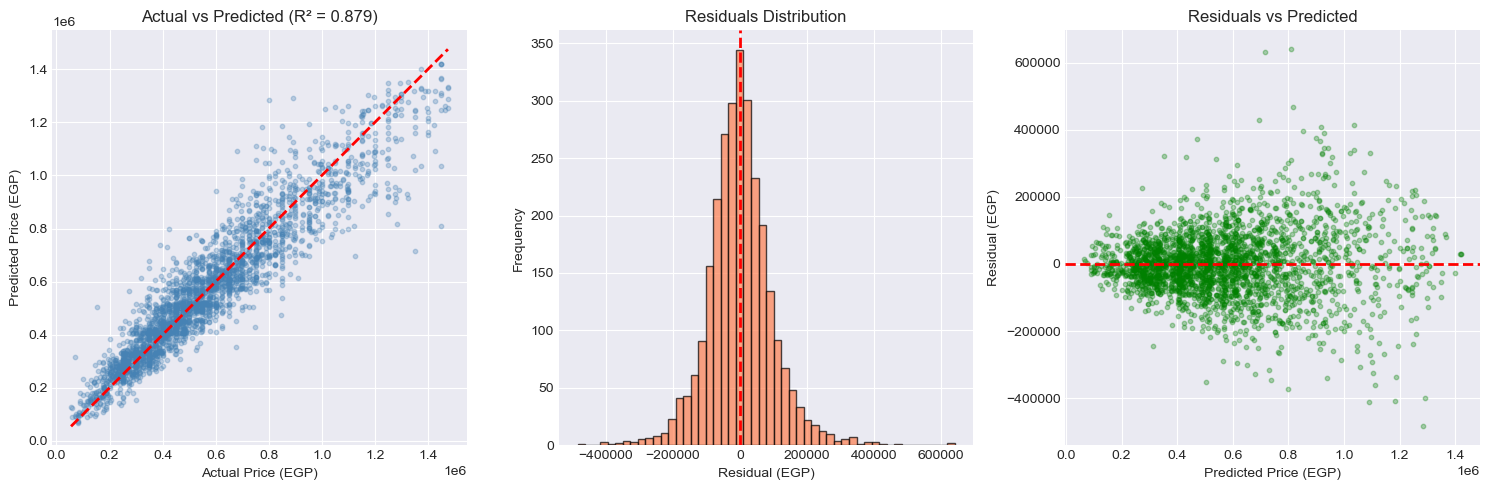

✅ Evaluation plots saved as 'model_evaluation.png'


In [16]:
# ============================================================
# 11. MODEL EVALUATION VISUALIZATIONS
# ============================================================
print("\n📈 11. MODEL EVALUATION VISUALIZATIONS")
print("-"*50)

# Predict on test set
if best_name in ['Linear Regression', 'Ridge (L2)', 'Lasso (L1)']:
    y_pred_final = best_model.predict(X_test_scaled)
else:
    y_pred_final = best_model.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred_final, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price (EGP)')
axes[0].set_ylabel('Predicted Price (EGP)')
axes[0].set_title(f'Actual vs Predicted (R² = {best_score:.3f})')

# 2. Residuals Distribution
residuals = y_test - y_pred_final
axes[1].hist(residuals, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (EGP)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution')

# 3. Residuals vs Predicted
axes[2].scatter(y_pred_final, residuals, alpha=0.3, s=10, color='green')
axes[2].axhline(y=0, color='red', linestyle='--', lw=2)
axes[2].set_xlabel('Predicted Price (EGP)')
axes[2].set_ylabel('Residual (EGP)')
axes[2].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation plots saved as 'model_evaluation.png'")

In [17]:
# ============================================================
# 12. SAVE EVERYTHING
# ============================================================
print("\n💾 12. SAVING ARTIFACTS")
print("-"*50)

# Save model
joblib.dump(best_model, 'best_model.pkl')
print("✅ Model saved as 'best_model.pkl'")

# Save encoders
joblib.dump(label_encoders, 'label_encoders.pkl')
print("✅ Encoders saved as 'label_encoders.pkl'")

# Save features list
joblib.dump(all_features, 'features.pkl')
print("✅ Features list saved as 'features.pkl'")

# Save scaler (if linear model, otherwise still save for consistency)
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved as 'scaler.pkl'")

# Save results summary
results_df = pd.DataFrame(results).T
results_df.to_csv('model_comparison.csv')
print("✅ Model comparison saved as 'model_comparison.csv'")

# Save final model metrics
final_metrics = {
    'model_name': best_name,
    'r2_score': best_score,
    'mae': mean_absolute_error(y_test, y_pred_final),
    'rmse': np.sqrt(mean_squared_error(y_test, y_pred_final)),
    'cv_mean': cv_scores.mean(),
    'cv_std': cv_scores.std()
}
pd.DataFrame([final_metrics]).to_csv('final_model_metrics.csv', index=False)
print("✅ Final metrics saved as 'final_model_metrics.csv'")



💾 12. SAVING ARTIFACTS
--------------------------------------------------
✅ Model saved as 'best_model.pkl'
✅ Encoders saved as 'label_encoders.pkl'
✅ Features list saved as 'features.pkl'
✅ Scaler saved as 'scaler.pkl'
✅ Model comparison saved as 'model_comparison.csv'
✅ Final metrics saved as 'final_model_metrics.csv'


In [18]:
# ============================================================
# 13. TEST PREDICTIONS
# ============================================================
print("\n🧪 13. SAMPLE PREDICTIONS")
print("-"*50)

test_cars = [
    {'brand': 'Hyundai', 'vehicle_age': 2, 'km_driven': 15000, 'fuel_type': 'Petrol',
     'transmission_type': 'Manual', 'seller_type': 'Dealer', 'engine': 1197, 'max_power': 82, 'seats': 5},
    
    {'brand': 'Toyota', 'vehicle_age': 10, 'km_driven': 150000, 'fuel_type': 'Diesel',
     'transmission_type': 'Manual', 'seller_type': 'Individual', 'engine': 1500, 'max_power': 100, 'seats': 5},
    
    {'brand': 'Mercedes-Benz', 'vehicle_age': 3, 'km_driven': 40000, 'fuel_type': 'Petrol',
     'transmission_type': 'Automatic', 'seller_type': 'Dealer', 'engine': 2000, 'max_power': 200, 'seats': 5}
]

for i, car in enumerate(test_cars, 1):
    # Encode
    encoded_input = [
        car['vehicle_age'],
        car['km_driven'],
        car['engine'],
        car['max_power'],
        car['seats'],
        label_encoders['brand'].transform([car['brand']])[0],
        label_encoders['fuel_type'].transform([car['fuel_type']])[0],
        label_encoders['transmission_type'].transform([car['transmission_type']])[0],
        label_encoders['seller_type'].transform([car['seller_type']])[0]
    ]
    
    # Predict
    price = best_model.predict([encoded_input])[0]
    print(f"\n🚗 Car {i}: {car['brand']} ({car['vehicle_age']} years, {car['km_driven']:,} km)")
    print(f"   💰 Predicted Price: {price:,.0f} EGP")



🧪 13. SAMPLE PREDICTIONS
--------------------------------------------------

🚗 Car 1: Hyundai (2 years, 15,000 km)
   💰 Predicted Price: 616,688 EGP

🚗 Car 2: Toyota (10 years, 150,000 km)
   💰 Predicted Price: 317,538 EGP

🚗 Car 3: Mercedes-Benz (3 years, 40,000 km)
   💰 Predicted Price: 1,231,854 EGP


In [19]:
# ============================================================
# 14. FINAL SUMMARY
# ============================================================
print("\n" + "="*70)
print("✅ MODEL TRAINING PIPELINE COMPLETE!")
print("="*70)
print(f"""
📊 FINAL RESULTS SUMMARY:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅ Best Model:        {best_name}
  ✅ R² Score:          {best_score:.4f} ({best_score*100:.2f}%)
  ✅ MAE:               {final_metrics['mae']:,.0f} EGP
  ✅ RMSE:              {final_metrics['rmse']:,.0f} EGP
  ✅ CV R² (mean):      {cv_scores.mean():.4f} ± {cv_scores.std():.4f}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📁 FILES GENERATED:
  • best_model.pkl              - Trained model
  • label_encoders.pkl          - Category encoders
  • features.pkl                - Feature list
  • scaler.pkl                  - Feature scaler
  • model_comparison.csv        - All models comparison
  • final_model_metrics.csv     - Best model metrics
  • feature_importance.png      - Feature importance plot
  • model_evaluation.png        - Evaluation plots
""")
print("="*70)


✅ MODEL TRAINING PIPELINE COMPLETE!

📊 FINAL RESULTS SUMMARY:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅ Best Model:        Random Forest
  ✅ R² Score:          0.8787 (87.87%)
  ✅ MAE:               71,212 EGP
  ✅ RMSE:              97,999 EGP
  ✅ CV R² (mean):      0.8603 ± 0.0049
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📁 FILES GENERATED:
  • best_model.pkl              - Trained model
  • label_encoders.pkl          - Category encoders
  • features.pkl                - Feature list
  • scaler.pkl                  - Feature scaler
  • model_comparison.csv        - All models comparison
  • final_model_metrics.csv     - Best model metrics
  • feature_importance.png      - Feature importance plot
  • model_evaluation.png        - Evaluation plots

